# Computing Outlier Scores from Scratch: Comprehensive Pipeline

A complete workflow for:
1. **Load pre-computed persistent homology results** using production loading functions
2. **Filter and process persistence diagrams** with best AUC selection
3. **Extract outlier detection scores** using topological features
4. **Benchmark multiple distance metrics** across noise levels and random seeds
5. **Generate publication-quality visualizations** similar to `plot_many_dists()`

This notebook demonstrates the full pipeline from pre-computed ripser results to quantitative comparison of distance metrics for outlier detection.

**Key Features:**
- Follows the exact pattern from `fig_all_methods_on_toy.ipynb`
- Uses production functions: `load_multiple_res()`, `filter_dgms()`, `get_outlier_scores_best_auc()`, `filter_dtm_dists()`, `plot_many_dists()`
- Scales to multiple noise levels (sigma), random seeds, and distance metrics
- Generates multi-panel subplots with mean/std error bands
- Selects best hyperparameter configurations automatically

## Section 1: Setup and Configuration

Import libraries, set up plotting styles, and configure paths and parameters.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rcParams

# Import production functions from the eff-ph project
from utils.utils import get_path, filter_dtm_dists
from utils.io_utils import load_multiple_res
from utils.pd_utils import get_outlier_scores_best_auc, filter_dgms
from utils.fig_utils import plot_many_dists
import utils.fig_utils as fig_utils  # Import module for accessing plotting attributes

# Set up plotting (optional: use project style if available)
try:
    style_file = "utils/style.mplstyle"
    plt.style.use(style_file)
except:
    pass

# Configure paths
root_path = get_path("data")
fig_path = os.path.join(root_path, "figures")

print("✓ Imports successful")
print(f"✓ Data path: {root_path}")
print(f"✓ Figure path: {fig_path}")

/opt/miniconda3/envs/eff-ph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[KeOps] Warning : There were warnings or errors :
/bin/sh: brew: command not found

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.

[KeOps] Warning : There were warnings or errors :
/bin/sh: brew: command not found

[KeOps] Warning : OpenMP library not found, it must be downloaded through Homebrew for apple Silicon chips
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


/Users/leova3397/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Code/Python Code/eff-ph/utils/utils.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


✓ Imports successful
✓ Data path: data
✓ Figure path: data/figures


## Section 2: Define Distance Metrics and Experimental Parameters

Configure which distance metrics and hyperparameters to benchmark.

In [2]:
# Define distance metrics and their hyperparameter configurations
# Matches fig_all_methods_on_toy.ipynb for comprehensive benchmarking
distances = {
    "euclidean": [{}],
    "fermat": [
        {"p": 2},
        {"p": 3},
        {"p": 5},
        {"p": 7}
    ],
    "dtm": [
        {"k": 4, "p_dtm": 2, "p_radius": 1},
        {"k": 4, "p_dtm": np.inf, "p_radius": 1},
        {"k": 15, "p_dtm": 2, "p_radius": 1},
        {"k": 15, "p_dtm": np.inf, "p_radius": 1},
        {"k": 100, "p_dtm": 2, "p_radius": 1},
        {"k": 100, "p_dtm": np.inf, "p_radius": 1},

        {"k": 4, "p_dtm": 2, "p_radius": 2},
        {"k": 4, "p_dtm": np.inf, "p_radius": 2},
        {"k": 15, "p_dtm": 2, "p_radius": 2},
        {"k": 15, "p_dtm": np.inf, "p_radius": 2},
        {"k": 100, "p_dtm": 2, "p_radius": 2},
        {"k": 100, "p_dtm": np.inf, "p_radius": 2},

        {"k": 4, "p_dtm": 2, "p_radius": np.inf},
        {"k": 4, "p_dtm": np.inf, "p_radius": np.inf},
        {"k": 15, "p_dtm": 2, "p_radius": np.inf},
        {"k": 15, "p_dtm": np.inf, "p_radius": np.inf},
        {"k": 100, "p_dtm": 2, "p_radius": np.inf},
        {"k": 100, "p_dtm": np.inf, "p_radius": np.inf},
    ],
    "core": [
        {"k": 15},
        {"k": 100}
    ],
    "sknn_dist": [
        {"k": 15},
        {"k": 100}
    ],
    "tsne": [
        {"perplexity": 30},
        {"perplexity": 200},
        {"perplexity": 333}
    ],
    "umap": [
        {"k": 100, "use_rho": True, "include_self": True},
        {"k": 999, "use_rho": True, "include_self": True},
    ],
    "tsne_embd": [
        {"perplexity": 8, "n_epochs": 500, "n_early_epochs": 250, "rescale_tsne": True},
        {"perplexity": 30, "n_epochs": 500, "n_early_epochs": 250, "rescale_tsne": True},
        {"perplexity": 333, "n_epochs": 500, "n_early_epochs": 250, "rescale_tsne": True}
    ],
    "umap_embd": [
        {"k": 15, "n_epochs": 750, "min_dist": 0.1, "metric": "euclidean"},
        {"k": 100, "n_epochs": 750, "min_dist": 0.1, "metric": "euclidean"},
        {"k": 999, "n_epochs": 750, "min_dist": 0.1, "metric": "euclidean"},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True}
    ],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "spectral": [
        {"k": 15, "normalization": "sym", "n_evecs": 2, "weighted": False},
        {"k": 15, "normalization": "sym", "n_evecs": 5, "weighted": False},
        {"k": 15, "normalization": "sym", "n_evecs": 10, "weighted": False},
    ],
}

# Experimental parameters
n = 1000  # Number of data points
d = 50    # Embedding dimension

#dataset ="toy_circle"  # Dataset name
dataset ="eyeglasses"  # Dataset name
#dataset = "inter_circles"
#dataset = "toy_sphere"

# Noise levels (sigma) to benchmark
sigmas = np.linspace(0.0, 0.4, 33)[:-4]
sigmas = np.array([np.format_float_positional(sigma, precision=4, unique=True, trim='0') 
                   for sigma in sigmas]).astype(float)

# Random seeds for reproducibility and uncertainty quantification
seeds = [0, 1, 2]

print(f"Configuration:")
print(f"  Dataset: {dataset}")
print(f"  n={n}, d={d}")
print(f"  Noise levels (sigmas): {len(sigmas)} values from {sigmas[0]:.4f} to {sigmas[-1]:.4f}")
print(f"  Seeds: {seeds}")
print(f"  Distance metrics: {list(distances.keys())}")
print(f"  Total combinations: {len(sigmas)} × {len(seeds)} × {sum(len(v) for v in distances.values())}")

Configuration:
  Dataset: eyeglasses
  n=1000, d=50
  Noise levels (sigmas): 29 values from 0.0000 to 0.3500
  Seeds: [0, 1, 2]
  Distance metrics: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'tsne_embd', 'umap_embd', 'eff_res', 'diffusion', 'spectral']
  Total combinations: 29 × 3 × 47


## Section 2.5: Compute Distances and Persistent Homology

**Note:** Skip this section if you have pre-computed ripser results on disk.

This section generates toy data and computes distance matrices and persistent homology for all metric configurations. This mimics the `compute_ph.py` script workflow.

In [3]:
# Import additional utilities for data generation and PH computation
from utils.toydata_utils import get_toy_data
from utils.dist_utils import get_dist
from utils.io_utils import dist_kwargs_to_str
from ripser import ripser
import os

# Set parameters matching Section 2 configurations
print(f"Configuration Setup:")
print(f"  Dataset: {dataset}")
print(f"  n={n}, d={d}")
print(f"  Noise levels (sigmas): {len(sigmas)} values")
print(f"  Seeds: {seeds}")
print(f"  Total computations: {len(sigmas)} × {len(seeds)} × {sum(len(v) for v in distances.values())} configs")


Configuration Setup:
  Dataset: eyeglasses
  n=1000, d=50
  Noise levels (sigmas): 29 values
  Seeds: [0, 1, 2]
  Total computations: 29 × 3 × 47 configs


## Section 2.5a: Train Quantum Kernel PQC (Optional)

**When to run this:**
- First time only: Train PQC parameters on clean reference data
- Save parameters to disk
- Then reuse in all benchmarking runs

**Training data:** Clean toy data (sigma=0.0) ensures the kernel learns core topology without noise interference.

### Quantum Kernel Training Workflow

**Step 1: Train (Run Section 2.5a)**
```
train_quantum_kernel = True
↓
Train PQC on clean data (sigma=0.0, seed=0)
↓
Save parameters to: {root_path}/{dataset}_quantum_kernel.npz
```

**Step 2: Benchmark (Run Sections 2.6 onwards)**
```
use_quantum_kernel = True
↓
Load pre-trained parameters
↓
Use SAME parameters for all noise levels (sigma=0.0 to 0.4)
↓
Compare against classical metrics
```

**Why train on sigma=0.0?**
- Learns pure topological structure without noise artifacts
- Parameters then generalize across noise levels (tests robustness)
- Standard practical approach: train baseline, test generalization
- Fair comparison: classical metrics aren't tuned per noise level either

**Key insight:** The quantum kernel optimization finds parameters that work well for the *task* (detecting topology), not for specific noise levels. This tests whether the learned kernel generalizes.

## Section 2.6: Load or Train Quantum Kernel (Optional)

**Important:** For quantum kernel integration, optimize PQC parameters **once per dataset**, then reuse across all noise levels.

This section loads pre-trained quantum kernel parameters. Skip if not using quantum kernels.

In [15]:
# ============================================================================
# QUANTUM KERNEL SETUP (Optional - only if including quantum kernel in distances)
# ============================================================================
# Important: PQC parameters are learned ONCE per dataset, then reused for all sigmas
# This tests generalization across noise levels

use_quantum_kernel = False  # Set to True if quantum kernel should be included

# Kernel evaluation (batched / landmarks)
def evaluate_kernel_batched(kernel, X, batch_size=500, use_landmarks=False, n_landmarks=2000):
    n_samples = X.shape[0]
    if use_landmarks and n_samples > n_landmarks:
        rng = np.random.RandomState(42)
        landmark_idx = rng.choice(n_samples, size=n_landmarks, replace=False)
        X_landmarks = X[landmark_idx]
        K_landmarks = kernel.evaluate(X_landmarks)
        K_dtl = np.zeros((n_samples, n_landmarks))
        for i in range(0, n_samples, batch_size):
            end_i = min(i + batch_size, n_samples)
            K_dtl[i:end_i] = kernel.evaluate(X[i:end_i], X_landmarks)
        return K_dtl, landmark_idx, K_landmarks
    K = np.zeros((n_samples, n_samples))
    for i in range(0, n_samples, batch_size):
        end_i = min(i + batch_size, n_samples)
        for j in range(i, n_samples, batch_size):
            end_j = min(j + batch_size, n_samples)
            if i == j:
                K_block = kernel.evaluate(X[i:end_i])
                K[i:end_i, i:end_i] = K_block
            else:
                K_block = kernel.evaluate(X[i:end_i], X[j:end_j])
                K[i:end_i, j:end_j] = K_block
                K[j:end_j, i:end_i] = K_block.T
    return K

def kernel_to_distance_matrix(K):
    """
    Converts a similarity matrix to a distance matrix with aggressive 
    safeguards against floating-point asymmetry and negative artifacts.
    """
    # 1. Calculate squared distances
    diag_K = np.diag(K)
    D_squared = diag_K[:, None] + diag_K[None, :] - 2 * K
    
    # 2. Aggressive zeroing of anything below 0
    D_squared[D_squared < 0] = 0.0
    
    # 3. Square root to get actual distances
    D = np.sqrt(D_squared)
    
    # 4. Enforce strict mathematical symmetry (D[i,j] MUST equal D[j,i])
    D = (D + D.T) / 2.0
    
    # 5. Final Paranoia Sweep: Zero out diagonal, kill negatives, and round off trailing garbage
    np.fill_diagonal(D, 0.0)
    D[D < 0] = 0.0
    D = np.round(D, 12) 
    
    # Force float64 format to keep scikit-learn happy
    return D.astype(np.float64)


import pennylane as qml
from squlearn.encoding_circuit import ChebyshevPQC
from squlearn.kernel import ProjectedQuantumKernel
from squlearn.util import Executor
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from numpy.linalg import eigvalsh

# === LOAD PRE-OPTIMIZED QUANTUM KERNEL ===
# Path to saved quantum kernel parameters (trained once per dataset)
#quantum_kernel_path = os.path.join(root_path, f"{dataset}_quantum_kernel.npz")

# 5 qubits, 4 layers = 
#quantum_kernel_path =  "/Users/leova3397/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Code/Python Code/eff-ph/data/PQCtrained/optimization_20260401_000630/opt_params_20260401_011521_projected quantum kernel_MMDPairwiseDistanceLoss_bestlayer3.npz"

# 10 qubits, 2 layers
#quantum_kernel_path =  "/Users/leova3397/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Code/Python Code/eff-ph/data/PQCtrained/optimization_20260331_235021/opt_params_20260401_020645_projected quantum kernel_MMDPairwiseDistanceLoss_bestlayer3.npz"

# 5 qubits, 4 layers, short ITER
#quantum_kernel_path =  "/Users/leova3397/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Code/Python Code/eff-ph/data/PQCtrained/optimization_20260331_235021/opt_params_20260401_020645_projected quantum kernel_MMDPairwiseDistanceLoss_bestlayer3.npz"




def compute_quantum_distance(X_test, 
                             opt_params, 
                             n_qubits, 
                             n_layers,
                             alpha_param,
                             gamma, 
                             nonlinearity,
                             d_reduce = 20):
    """
    Compute quantum kernel distance matrix for a dataset.
    
    Args:
        X_test: Data array (n_samples, n_features)
        opt_params: Pre-optimized PQC parameters (same for all sigma!)
        n_qubits: Number of qubits
        n_layers: Number of PQC layers
        d_reduce: Dimension for PCA reduction
    
    Returns:
        Distance matrix (n_samples, n_samples)
    """

    # PCA reduction to match qubit count
    if X_test.shape[1] > d_reduce:
        pca = PCA(n_components=d_reduce)
        X_reduced = pca.fit_transform(X_test)
    else:
        X_reduced = X_test
    
    # Scale to Chebyshev domain [-0.9, 0.9]
    scaler = MinMaxScaler(feature_range=(-0.9, 0.9))
    X_scaled = scaler.fit_transform(X_reduced)
    
    # Create quantum circuit (same structure for all sigmas!)
    dev = qml.device("lightning.qubit", wires=n_qubits)
    executor = Executor(dev)
    
    enc_circ = ChebyshevPQC(
        num_qubits=n_qubits,
        num_layers=n_layers,
        entangling_gate='rzz',
        alpha=alpha_param,
        nonlinearity=nonlinearity
    )
    
    q_kernel = ProjectedQuantumKernel(
        encoding_circuit=enc_circ,
        executor=executor,
        measurement="XYZ",
        outer_kernel="gaussian",
        initial_parameters=opt_params,  # USE SAME PARAMETERS FOR ALL SIGMAS!
        gamma=gamma
    )
    
    q_kernel.assign_parameters(opt_params)
    
    # Evaluate kernel and convert to distance
    K_quantum = evaluate_kernel_batched(q_kernel, X_scaled, batch_size=500)
    K_quantum = 0.5 * (K_quantum + K_quantum.T)
    K_quantum[np.isnan(K_quantum)] = 0.0
    
    D_quantum = kernel_to_distance_matrix(K_quantum)
    return D_quantum

if use_quantum_kernel:
    # Add quantum to distances dict
    if "quantum" not in distances:
        distances["quantum"] = [{}]  # Will be computed separately
    print("\n✓ Quantum kernel ready for computation")

#### Change distances as needed

In [85]:
#dataset ="toy_circle"  # Dataset name
#dataset ="eyeglasses"  # Dataset name
#dataset = "inter_circles"
dataset = "toy_sphere"

In [18]:
print("\n" + "="*80)
print("COMPUTING DISTANCES AND PERSISTENT HOMOLOGY")
print("="*80)
print("This may take several minutes depending on number of metrics and configurations...")
print("(Note: Quantum kernels will be computed separately in Section 2.7)\n")

# Counter for tracking progress
total_configs = len(sigmas) * len(seeds) * sum(len(v) for v in distances.values())
configs_completed = 0

# Create dataset subdirectory if it doesn't exist
dataset_path = os.path.join(root_path, dataset)
os.makedirs(dataset_path, exist_ok=True)

# Main computation loop
for seed in seeds:
    for sigma in sigmas:
        # Generate toy data for this (sigma, seed) combination
        x = get_toy_data(n=n, dataset=dataset, d=d, seed=seed, gaussian={"sigma": sigma})
        
        # Compute distances and PH for each distance metric and configuration
        for distance in distances:
            # Skip quantum kernels (computed separately in Section 2.7)
            if "quantum" in distance:
                print(f"⊘ Skipping {distance} (will be computed separately in Section 2.7)")
                continue
            
            for dist_kwargs in distances[distance]:
                configs_completed += 1
                progress_pct = (configs_completed / total_configs) * 100
                
                # Create configuration string for file naming
                config_str = dist_kwargs_to_str(dist_kwargs)
                file_name = f"{dataset}_{n}_d_{d}_ortho_gauss_sigma_{sigma}_seed_{seed}_{distance}{config_str}"
                file_path = os.path.join(dataset_path, file_name + "_rep")
                
                # Skip if result already exists
                if os.path.exists(file_path):
                    print(f"[{progress_pct:5.1f}%] ✓ Skipped {distance:15s} {config_str:30s} (already computed)")
                    continue
                
                try:
                    # Compute distance matrix
                    dists = get_dist(x=x, distance=distance, **dist_kwargs)
                    
                    # Compute persistent homology
                    result = ripser(dists, maxdim=1, distance_matrix=True)
                    dgms = result['dgms']
                    
                    # Save result to disk using numpy savez format
                    # This matches the format expected by load_multiple_res()
                    save_dict = {
                        'dgm_0d': dgms[0],  # 0D features (components)
                        'dgm_1d': dgms[1],  # 1D features (loops)
                    }
                    np.savez(file_path, **save_dict)
                    
                    print(f"[{progress_pct:5.1f}%] ✓ Computed {distance:15s} {config_str:30s}")
                    
                except Exception as e:
                    print(f"[{progress_pct:5.1f}%] ✗ Error {distance:15s} {config_str:30s}: {str(e)[:50]}")

print("\n" + "="*80)
print(f"✓ Classical metrics computation complete! Processed {configs_completed}/{total_configs} configurations")
print(f"✓ Results saved to: {dataset_path}")
print("="*80)


COMPUTING DISTANCES AND PERSISTENT HOMOLOGY
This may take several minutes depending on number of metrics and configurations...
(Note: Quantum kernels will be computed separately in Section 2.7)

[  0.0%] ✓ Computed euclidean                                     
[  0.0%] ✓ Computed fermat          _p_2                          
[  0.1%] ✓ Computed fermat          _p_3                          
[  0.1%] ✓ Computed fermat          _p_5                          
[  0.1%] ✓ Computed fermat          _p_7                          
[  0.1%] ✓ Computed dtm             _k_4_p_dtm_2_p_radius_1       


KeyboardInterrupt: 

## Section 2.7: Compute Quantum Kernel Distances (Separate)

**Purpose:** Calculate quantum kernel distances separately for both 4-qubit and 5-qubit variants, then save in the same `.npz` format as classical metrics.

**Why separate?** Quantum kernel computation is expensive, so we compute once and cache to disk for reuse across all parameters.


In [ ]:
# if we do not set this one, it will be just overriden by the latest one.
QUANTUM_CONFIG_MANIFEST = 

In [ ]:
# ============================================================================
# QUANTUM KERNEL SETUP (Optional - only if including quantum kernel in distances)
# ============================================================================
# Important: PQC parameters are learned once per dataset, then reused for all sigmas.
# The notebook now loads the finalized quantum configuration list from the
# pipeline-generated manifest written by run_full_pqc_pipeline.sh.

from pathlib import Path

use_quantum_kernel = False  # Set to True if quantum kernel should be included

# Kernel evaluation helpers (batched / landmarks)
def evaluate_kernel_batched(kernel, X, batch_size=500, use_landmarks=False, n_landmarks=2000):
    n_samples = X.shape[0]
    if use_landmarks and n_samples > n_landmarks:
        rng = np.random.RandomState(42)
        landmark_idx = rng.choice(n_samples, size=n_landmarks, replace=False)
        X_landmarks = X[landmark_idx]
        K_landmarks = kernel.evaluate(X_landmarks)
        K_dtl = np.zeros((n_samples, n_landmarks))
        for i in range(0, n_samples, batch_size):
            end_i = min(i + batch_size, n_samples)
            K_dtl[i:end_i] = kernel.evaluate(X[i:end_i], X_landmarks)
        return K_dtl, landmark_idx, K_landmarks

    K = np.zeros((n_samples, n_samples))
    for i in range(0, n_samples, batch_size):
        end_i = min(i + batch_size, n_samples)
        for j in range(i, n_samples, batch_size):
            end_j = min(j + batch_size, n_samples)
            if i == j:
                K_block = kernel.evaluate(X[i:end_i])
                K[i:end_i, i:end_i] = K_block
            else:
                K_block = kernel.evaluate(X[i:end_i], X[j:end_j])
                K[i:end_i, j:end_j] = K_block
                K[j:end_j, i:end_i] = K_block.T
    return K


def kernel_to_distance_matrix(K):
    """
    Converts a similarity matrix to a distance matrix with aggressive
    safeguards against floating-point asymmetry and negative artifacts.
    """
    diag_K = np.diag(K)
    D_squared = diag_K[:, None] + diag_K[None, :] - 2 * K
    D_squared[D_squared < 0] = 0.0
    D = np.sqrt(D_squared)
    D = (D + D.T) / 2.0
    np.fill_diagonal(D, 0.0)
    D[D < 0] = 0.0
    D = np.round(D, 12)
    return D.astype(np.float64)


def find_latest_quantum_manifest(dataset_name, pipeline_root):
    pattern = f"{dataset_name}_*/stage5_notebook_payload/quantum_configs_for_notebook.json"
    candidates = sorted(Path(pipeline_root).glob(pattern))
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


# Load the finalized quantum config manifest created by the full pipeline.
pipeline_root = Path(os.environ.get("PQC_PIPELINE_ROOT", "/data/gpfs/projects/punim0613/zuzana/qphate/results/pqc_full_pipeline"))
manifest_override = os.environ.get("QUANTUM_CONFIG_MANIFEST", "").strip()
manifest_path = Path(manifest_override) if manifest_override else find_latest_quantum_manifest(dataset, pipeline_root)
quantum_configs = []

if manifest_path is not None and manifest_path.exists():
    with manifest_path.open("r") as handle:
        quantum_manifest = json.load(handle)
    quantum_configs = quantum_manifest.get("quantum_configs", [])
    print(f"✓ Loaded quantum config manifest: {manifest_path}")
    print(f"✓ Quantum configs available: {len(quantum_configs)}")
    for config in quantum_configs:
        print(f"  - {config.get('name')} -> {config.get('path')}")
else:
    print("⚠ No quantum config manifest found.")
    print("  Set QUANTUM_CONFIG_MANIFEST or place pipeline output under PQC_PIPELINE_ROOT.")
    print("  The notebook will continue with classical-only analysis.")


def compute_quantum_distance(X_test,
                             opt_params,
                             n_qubits,
                             n_layers,
                             alpha_param,
                             gamma,
                             nonlinearity,
                             d_reduce=20):
    """
    Compute quantum kernel distance matrix for a dataset.

    Args:
        X_test: Data array (n_samples, n_features)
        opt_params: Pre-optimized PQC parameters (same for all sigma!)
        n_qubits: Number of qubits
        n_layers: Number of PQC layers
        d_reduce: Dimension for PCA reduction

    Returns:
        Distance matrix (n_samples, n_samples)
    """

    if X_test.shape[1] > d_reduce:
        pca = PCA(n_components=d_reduce)
        X_reduced = pca.fit_transform(X_test)
    else:
        X_reduced = X_test

    scaler = MinMaxScaler(feature_range=(-0.9, 0.9))
    X_scaled = scaler.fit_transform(X_reduced)

    dev = qml.device("lightning.qubit", wires=n_qubits)
    executor = Executor(dev)

    enc_circ = ChebyshevPQC(
        num_qubits=n_qubits,
        num_layers=n_layers,
        entangling_gate='rzz',
        alpha=alpha_param,
        nonlinearity=nonlinearity
    )

    q_kernel = ProjectedQuantumKernel(
        encoding_circuit=enc_circ,
        executor=executor,
        measurement="XYZ",
        outer_kernel="gaussian",
        initial_parameters=opt_params,
        gamma=gamma
    )

    q_kernel.assign_parameters(opt_params)

    K_quantum = evaluate_kernel_batched(q_kernel, X_scaled, batch_size=500)
    K_quantum = 0.5 * (K_quantum + K_quantum.T)
    K_quantum[np.isnan(K_quantum)] = 0.0

    D_quantum = kernel_to_distance_matrix(K_quantum)
    return D_quantum

if use_quantum_kernel:
    if "quantum" not in distances:
        distances["quantum"] = [{}]
    print("\n✓ Quantum kernel ready for computation")



COMPUTING QUANTUM KERNEL DISTANCES (Separate)
Computing 4-qubit and 5-qubit quantum kernel variants...


Computing quantum_5q (5 qubits, 4 layers)
✓ Loaded quantum kernel from: /Users/leova3397/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Code/Python Code/eff-ph/data/PQCtrained/toy_sphere/optimization_20260403_173247/opt_params_20260403_200203_projected quantum kernel_MMDPairwiseDistanceLoss_bestlayer4.npz
[  0.2%] ✓ Computed quantum_5q sigma=0.000 seed=0
[  0.5%] ✓ Computed quantum_5q sigma=0.013 seed=0
[  0.7%] ✓ Computed quantum_5q sigma=0.025 seed=0
[  0.9%] ✓ Computed quantum_5q sigma=0.037 seed=0
[  1.1%] ✓ Computed quantum_5q sigma=0.050 seed=0
[  1.4%] ✓ Computed quantum_5q sigma=0.062 seed=0
[  1.6%] ✓ Computed quantum_5q sigma=0.075 seed=0
[  1.8%] ✓ Computed quantum_5q sigma=0.087 seed=0
[  2.1%] ✓ Computed quantum_5q sigma=0.100 seed=0
[  2.3%] ✓ Computed quantum_5q sigma=0.113 seed=0
[  2.5%] ✓ Computed quantum_5q sigma=0.125 seed=0
[  2.8%] ✓ Computed quantum_5

## Section 2.8: Update Distances Dictionary for Loading

Add all quantum kernel variants to the distances dictionary so they will be loaded by `load_multiple_res()` in Section 3 and **automatically included in all downstream analysis and plots**.

**Pipeline Integration:**
- ✓ **Loaded** in Section 3 (auto-discovered from disk)
- ✓ **Filtered** in Section 4 (same as classical metrics)
- ✓ **Scored** in Section 5 (outlier detection computed)
- ✓ **Plotted** in Section 7 (appears in multi-panel figure)
- ✓ **Analyzed** in Section 8 (ranked with other metrics)

In [ ]:
print("Updating distances dictionary with computed quantum kernel variants...\n")

# Extract quantum kernel names from the quantum_configs already defined in Section 2.7
# This ensures we only try to load quantum metrics that were actually computed
quantum_kernel_names = [config["name"] for config in quantum_configs]

print(f"Quantum configs found for dataset '{dataset}':")
print(f"  {quantum_kernel_names}\n")

# Add ONLY the quantum variants that exist in quantum_configs to distances dict
for quantum_name in quantum_kernel_names:
    distances[quantum_name] = [{}]

print(f"✓ Added {len(quantum_kernel_names)} quantum kernel variants to distances:")
for name in quantum_kernel_names:
    print(f"  - {name}")

print(f"\n✓ All {len([k for k in distances.keys() if 'quantum' in k])} quantum kernels will be included in plots!")
print(f"\nUpdated distances dictionary keys: {list(distances.keys())}")
print(f"Total metrics: {len(distances)} (including {len([k for k in distances.keys() if 'quantum' in k])} quantum variants)")

Updating distances dictionary with computed quantum kernel variants...

Quantum configs found for dataset 'inter_circles':
  ['quantum_5q', 'quantum_10q', 'quantum_7q_3l', 'quantum_7q_3l_arctan']

✓ Added 4 quantum kernel variants to distances:
  - quantum_5q
  - quantum_10q
  - quantum_7q_3l
  - quantum_7q_3l_arctan

✓ All 11 quantum kernels will be included in plots!

Updated distances dictionary keys: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'tsne_embd', 'umap_embd', 'eff_res', 'diffusion', 'spectral', 'quantum_5q', 'quantum_10q', 'quantum_5q_v2', 'quantum_4q_2l', 'quantum_6q_3l_arctan', 'quantum_6q_3l', 'quantum_7q_3l', 'quantum_7q_3l_arctan', 'quantum_5q_3q', 'quantum_5q_3q_arctan', 'quantum_5q_3l']
Total metrics: 23 (including 11 quantum variants)


### Output File Structure

The computation creates `.npz` files in the data directory following this pattern:

```
{root_path}/{dataset}/
  ├── {dataset}_{n}_d_{d}_ortho_gauss_sigma_0.0_seed_0_euclidean_rep.npz
  ├── {dataset}_{n}_d_{d}_ortho_gauss_sigma_0.0_seed_0_fermat_p_2_rep.npz
  ├── {dataset}_{n}_d_{d}_ortho_gauss_sigma_0.0_seed_0_dtm_k_4_p_dtm_2_p_radius_1_rep.npz
  └── ... (one file per metric configuration, seed, and noise level)
```

**File Contents:**
- `dgm_0d`: 0-dimensional persistence diagram (connected components)
- `dgm_1d`: 1-dimensional persistence diagram (loops/holes)

These `.npz` files are automatically discovered and loaded by `load_multiple_res()` in the next step.

## Section 3: Load Pre-Computed Persistent Homology Results

Use `load_multiple_res()` to load ripser results from disk. This follows the production workflow from `fig_all_methods_on_toy.ipynb`.

**Prerequisites:**
- Either run Section 2.5 above to compute distances and PH, OR
- Have pre-computed ripser results on disk following the naming convention: `{dataset}_{n}_d_{d}_ortho_gauss_sigma_{sigma}_seed_{seed}_{distance}{config}_rep.npz`

This step automatically discovers and loads all `.npz` files from the dataset directory.

In [ ]:
# Load the updated io_utils with .npz support
from utils.io_utils_modified import load_multiple_res

print("="*80)
print("READY: Quantum distances will be loaded from disk")
print("="*80)
print("The following quantum kernels will be loaded (if files exist):")
quantum_in_distances = [k for k in distances.keys() if 'quantum' in k]
for q_variant in quantum_in_distances:
    print(f"  ✓ {q_variant}")
print("These will automatically appear in plots after filtering and scoring.")
print("="*80)

READY: Quantum distances will be loaded from disk
The following quantum kernels will be loaded (if files exist):
  ✓ quantum_5q
  ✓ quantum_10q
  ✓ quantum_5q_v2
  ✓ quantum_4q_2l
  ✓ quantum_6q_3l_arctan
  ✓ quantum_6q_3l
  ✓ quantum_7q_3l
  ✓ quantum_7q_3l_arctan
  ✓ quantum_5q_3q
  ✓ quantum_5q_3q_arctan
  ✓ quantum_5q_3l
These will automatically appear in plots after filtering and scoring.


In [ ]:
# Load all persistent homology results using the production function
# This loads pre-computed ripser results from disk
print("Loading pre-computed ripser results...")
print(f"  Dataset: {dataset}")
print(f"  Path: {root_path}")

if dataset=="eyeglasses":
    
    all_res = load_multiple_res(
        datasets=dataset, 
        distances=distances, 
        root_path=root_path, 
        n=n, 
        embd_dims=d, 
        sigmas=sigmas[:13], 
        seeds=seeds, 
        n_threads=10  # Parallel loading
    )
else:
    all_res = load_multiple_res(
        datasets=dataset, 
        distances=distances, 
        root_path=root_path, 
        n=n, 
        embd_dims=d, 
        sigmas=sigmas, 
        seeds=seeds, 
        n_threads=10  # Parallel loading
    )

print(f"✓ Loaded results for {dataset}")
print(f"✓ Structure keys: {list(all_res.keys())}")

# Show a sample of loaded data structure
sample_dist = list(all_res.keys())[0]
sample_config = list(all_res[sample_dist].keys())[0]
print(f"\nSample result structure:")
print(f"  Distance: {sample_dist}")
print(f"  Config: {sample_config}")
print(f"  Type: {type(all_res[sample_dist][sample_config])}")

Loading pre-computed ripser results...
  Dataset: inter_circles
  Path: data
Done with inter_circles 50 euclidean n_outliers=0, perturbation=None
Done with inter_circles 50 fermat_p_2 n_outliers=0, perturbation=None
Done with inter_circles 50 fermat_p_3 n_outliers=0, perturbation=None
Done with inter_circles 50 fermat_p_5 n_outliers=0, perturbation=None
Done with inter_circles 50 fermat_p_7 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_4_p_dtm_2_p_radius_1 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_4_p_dtm_inf_p_radius_1 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_15_p_dtm_2_p_radius_1 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_15_p_dtm_inf_p_radius_1 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_100_p_dtm_2_p_radius_1 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_100_p_dtm_inf_p_radius_1 n_outliers=0, perturbation=None
Done with inter_circles 50 dtm_k_4_p_dtm_2_p_r

In [ ]:
## Diagnostic: Check for None values in loaded results

print("\n" + "="*80)
print("DIAGNOSTIC: Checking data structure integrity")
print("="*80)

def find_none_values(obj, path=""):
    """Recursively find None values in nested dictionaries"""
    none_locations = []
    
    if obj is None:
        none_locations.append(path if path else "ROOT")
    elif isinstance(obj, dict):
        for key, value in obj.items():
            new_path = f"{path}[{key}]" if path else str(key)
            none_locations.extend(find_none_values(value, new_path))
    elif isinstance(obj, list):
        for i, value in enumerate(obj):
            new_path = f"{path}[{i}]"
            none_locations.extend(find_none_values(value, new_path))
    
    return none_locations

# Check for None values
none_locations = find_none_values(all_res)

if none_locations:
    print(f"\n⚠ Found {len(none_locations)} None values in loaded results:")
    for loc in none_locations[:10]:  # Show first 10
        print(f"  - {loc}")
    if len(none_locations) > 10:
        print(f"  ... and {len(none_locations) - 10} more")
    
    print(f"\nThese indicate missing or failed distance computations.")
    print(f"Check if the following files exist:")
    print(f"  Location: {dataset_path}")
else:
    print(f"✓ No None values found - all data loaded successfully!")

# Show summary of loaded distances
print(f"\n{'='*80}")
print("Summary of loaded distance metrics:")
print(f"{'='*80}")
for dist in sorted(all_res.keys()):
    n_configs = len(all_res[dist])
    print(f"  {dist:<20s}: {n_configs} configurations")



DIAGNOSTIC: Checking data structure integrity

⚠ Found 1131 None values in loaded results:
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.0][0]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.0][1]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.0][2]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.0125][0]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.0125][1]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.0125][2]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.025][0]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.025][1]
  - tsne_embd[tsne_embd_perplexity_8_n_epochs_500_n_early_epochs_250_rescale_tsne_True][0.025][2]
  - tsne_embd[tsne_embd_perpl

In [ ]:
## Fix: Update distances dictionary to match computed data

print("\n" + "="*80)
print("FIXING: Updating distances dictionary to match computed metrics")
print("="*80)

# Get list of metrics that actually have data
computed_metrics = list(all_res.keys())
print(f"\nActually computed metrics: {computed_metrics}")

# Identify which metrics from distances dict are missing
missing_metrics = [m for m in distances.keys() if m not in computed_metrics]
print(f"Missing metrics (will be removed): {missing_metrics}")

# Update distances dict to only include computed metrics
distances_updated = {k: v for k, v in distances.items() if k in computed_metrics}

print(f"\nUpdated distances dictionary:")
print(f"  Before: {len(distances)} metrics")
print(f"  After:  {len(distances_updated)} metrics")
print(f"  Removed: {', '.join(missing_metrics) if missing_metrics else 'None'}")

# Use the updated dictionary
distances = distances_updated

print(f"\nRestored distances keys: {list(distances.keys())}")



FIXING: Updating distances dictionary to match computed metrics

Actually computed metrics: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'tsne_embd', 'umap_embd', 'eff_res', 'diffusion', 'spectral', 'quantum_5q', 'quantum_10q', 'quantum_5q_v2', 'quantum_4q_2l', 'quantum_6q_3l_arctan', 'quantum_6q_3l', 'quantum_7q_3l', 'quantum_7q_3l_arctan', 'quantum_5q_3q', 'quantum_5q_3q_arctan', 'quantum_5q_3l']
Missing metrics (will be removed): []

Updated distances dictionary:
  Before: 23 metrics
  After:  23 metrics
  Removed: None

Restored distances keys: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'tsne_embd', 'umap_embd', 'eff_res', 'diffusion', 'spectral', 'quantum_5q', 'quantum_10q', 'quantum_5q_v2', 'quantum_4q_2l', 'quantum_6q_3l_arctan', 'quantum_6q_3l', 'quantum_7q_3l', 'quantum_7q_3l_arctan', 'quantum_5q_3q', 'quantum_5q_3q_arctan', 'quantum_5q_3l']


## Section 4: Filter Persistence Diagrams

Apply death/birth (dob) ratio filtering to remove noise features while preserving signal topology.

In [ ]:
print("Cleaning and filtering persistence diagrams...")

# First, remove any distance metrics with None values
def remove_none_values(obj):
    """Recursively remove None values from nested dictionaries"""
    if isinstance(obj, dict):
        result = {}
        for key, value in obj.items():
            cleaned = remove_none_values(value)
            if cleaned is not None:  # Only include if not None
                result[key] = cleaned
        return result if result else None
    else:
        return obj

all_res = remove_none_values(all_res)

print(f"✓ Removed metrics with missing data")
print(f"✓ Remaining metrics: {list(all_res.keys())}")

# Now filter by death/birth ratio (dob = 1.25)
# This removes noise features (small lifetimes) while preserving signal features
dob = 1.25
all_res = filter_dgms(all_res, dim=1, dob=dob, binary=True)

print(f"✓ Filtered diagrams with dob={dob} (binary mode)")
print(f"  dim=1 (loops)")
print(f"  Removes noise features with poor death/birth ratios")

Cleaning and filtering persistence diagrams...
✓ Removed metrics with missing data
✓ Remaining metrics: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'eff_res', 'diffusion', 'spectral', 'quantum_5q', 'quantum_10q', 'quantum_7q_3l', 'quantum_7q_3l_arctan']
✓ Filtered diagrams with dob=1.25 (binary mode)
  dim=1 (loops)
  Removes noise features with poor death/birth ratios


## Section 5: Compute Outlier Scores and Select Best Hyperparameters

Use `get_outlier_scores_best_auc()` to compute detection scores and automatically select best hyperparameter configurations for each distance metric.

**Outlier Score Formula:**
$$\text{Score} = \frac{\text{lifetime}_{\text{max}} - \text{lifetime}_{\text{next}}}{\text{lifetime}_{\text{max}}}$$

- **High score (>0.8):** Excellent separation between signal and noise
- **Low score (<0.2):** Poor separation, metric fails to detect topological signal

In [ ]:
print("Computing outlier scores...")

# CRITICAL: Clean all_res to remove metrics with None values
# This prevents TypeError in compute_outlier_scores_recursive()
print("\nCleaning all_res before computation...")
print("Checking for None values in loaded data...")

def has_none_values(obj):
    """Check if nested dict structure contains any None values"""
    if obj is None:
        return True
    elif isinstance(obj, dict):
        return any(has_none_values(v) for v in obj.values())
    elif isinstance(obj, (list, tuple)):
        return any(has_none_values(v) for v in obj)
    return False

# Remove metrics that have any None values anywhere in their structure
metrics_with_none = []
for metric in list(all_res.keys()):
    if has_none_values(all_res[metric]):
        metrics_with_none.append(metric)
        del all_res[metric]

if metrics_with_none:
    print(f"⚠ Removed {len(metrics_with_none)} metric(s) with incomplete data:")
    for m in metrics_with_none:
        print(f"    - {m}")
else:
    print(f"✓ All metrics have valid data")

print(f"✓ Proceeding with {len(all_res)} valid metrics: {list(all_res.keys())}\n")

# Compute outlier scores for each metric configuration
# Returns: (outlier_scores, best_aucs)
# outlier_scores[metric][config] = array of shape (len(sigmas), len(seeds))
# best_aucs[metric] = {"run": config_name, "auc": average_score}

try:
    outlier_scores, best_aucs = get_outlier_scores_best_auc(
        all_res, 
        dim=1,        # 1D features (loops)
        n_features=1  # Expecting 1 ground truth feature (the circle)
    )
except TypeError as e:
    print(f"✗ Error computing outlier scores: {e}")
    print(f"  This may indicate corrupted data structures in all_res")
    print(f"  Try re-running Section 3 (Load Pre-Computed Results) and Section 4 (Filter)")
    raise

print(f"✓ Computed outlier scores")
print(f"  Distance metrics: {list(outlier_scores.keys())}")
print(f"  Scores shape: (n_sigmas={len(sigmas)}, n_seeds={len(seeds)})")

# Show which quantum kernels are included
quantum_metrics = [k for k in outlier_scores.keys() if 'quantum' in k]
if quantum_metrics:
    print(f"\n✓ Quantum kernels included in analysis:")
    for q_metric in quantum_metrics:
        print(f"    - {q_metric}")
else:
    print(f"\n⚠ No quantum kernels found in data (may not have been computed yet)")

# Display best configurations for each metric
print(f"\nBest hyperparameter configurations (by AUC):")
print(f"{'Metric':<20} {'Config':<50} {'AUC Score':<15}")
print("="*85)
for metric in sorted(best_aucs.keys()):
    config = best_aucs[metric]["run"]
    auc = best_aucs[metric]["auc"]
    print(f"{metric:<20} {config:<50} {auc:>8.4f}")

Computing outlier scores...

Cleaning all_res before computation...
Checking for None values in loaded data...
✓ All metrics have valid data
✓ Proceeding with 14 valid metrics: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'eff_res', 'diffusion', 'spectral', 'quantum_5q', 'quantum_10q', 'quantum_7q_3l', 'quantum_7q_3l_arctan']

✓ Computed outlier scores
  Distance metrics: ['euclidean', 'fermat', 'dtm', 'core', 'sknn_dist', 'tsne', 'umap', 'eff_res', 'diffusion', 'spectral', 'quantum_5q', 'quantum_10q', 'quantum_7q_3l', 'quantum_7q_3l_arctan']
  Scores shape: (n_sigmas=29, n_seeds=3)

✓ Quantum kernels included in analysis:
    - quantum_5q
    - quantum_10q
    - quantum_7q_3l
    - quantum_7q_3l_arctan

Best hyperparameter configurations (by AUC):
Metric               Config                                             AUC Score      
core                 core_k_15                                            0.0198
diffusion            diffusion_k_15_t_8_kernel_sk

## Section 6: Filter DTM Configurations

For DTM distance, keep only the best configuration for each p_radius value. This reduces visualization clutter while preserving the best performing variant of each DTM type.

In [ ]:
print("Filtering DTM configurations...")

# Filter DTM: keep only best configuration for each p_radius value
filter_dtm_dists(outlier_scores)

print(f"✓ Filtered DTM configurations")
print(f"  Kept best config for each p_radius ∈ [1, 2, ∞]")
print(f"  Remaining DTM configs: {list(outlier_scores.get('dtm', {}).keys())}")

Filtering DTM configurations...
dict_keys(['dtm_k_4_p_dtm_inf_p_radius_1', 'dtm_k_15_p_dtm_inf_p_radius_2', 'dtm_k_15_p_dtm_inf_p_radius_inf'])
✓ Filtered DTM configurations
  Kept best config for each p_radius ∈ [1, 2, ∞]
  Remaining DTM configs: ['dtm_k_4_p_dtm_inf_p_radius_1', 'dtm_k_15_p_dtm_inf_p_radius_2', 'dtm_k_15_p_dtm_inf_p_radius_inf']


## Section 7: Generate Publication-Quality Visualizations

Create comprehensive multi-panel subplots showing outlier detection scores vs noise level for all distance metrics. This uses the production `plot_many_dists()` function from `fig_utils.py`.

**Visualization Layout:**
- 3×4 grid of subplots (one per distance metric, except euclidean as baseline)
- Each subplot shows multiple configurations as colored lines
- Error bands show ±1 standard deviation across seeds
- Dashed black line shows euclidean baseline for reference
- Euclidean score appears as reference in each non-euclidean panel

In [ ]:
# FIX: Detect actual number of sigmas loaded (vary by dataset)
# For eyeglasses, only first 13 sigmas were loaded; extract from data shape
n_sigmas_actual = outlier_scores["euclidean"]["euclidean"].shape[0]
sigmas_actual = sigmas[:n_sigmas_actual]  # Use only the sigmas that were actually loaded

print(f"Data shape: {outlier_scores['euclidean']['euclidean'].shape}")
print(f"Number of sigmas loaded: {n_sigmas_actual} (full: {len(sigmas)})")
print(f"Using sigmas: {sigmas_actual}")

# MERGE: Combine all quantum_* metrics into a single "quantum" entry
# This allows all quantum configs to appear in ONE subplot instead of separate ones
print("\n" + "="*70)
print("MERGING quantum metrics into single aggregated 'quantum' metric")
print("="*70)

quantum_keys = [k for k in outlier_scores.keys() if k.startswith('quantum_')]
print(f"\nBefore merging:")
print(f"  Total metrics: {len(outlier_scores)}")
print(f"  Individual quantum metrics found: {quantum_keys}")

if quantum_keys:
    print(f"\nMerging {len(quantum_keys)} separate quantum metrics...")
    
    # Create merged quantum entry with all configurations
    merged_quantum = {}
    for quantum_key in quantum_keys:
        configs_in_this_metric = list(outlier_scores[quantum_key].keys())
        print(f"  - {quantum_key}: {configs_in_this_metric}")
        for config_key, data in outlier_scores[quantum_key].items():
            merged_quantum[config_key] = data
    
    # Remove individual quantum metrics
    for quantum_key in quantum_keys:
        del outlier_scores[quantum_key]
    
    # Add merged quantum metric
    outlier_scores["quantum"] = merged_quantum
    print(f"\n✓ Successfully merged quantum metrics!")
    print(f"  - Removed {len(quantum_keys)} individual quantum metric entries")
    print(f"  - Created single 'quantum' metric with {len(merged_quantum)} configurations:")
    for config in sorted(merged_quantum.keys()):
        print(f"    • {config}")
    print(f"\n✓ All quantum variants will now appear in ONE subplot with overlaid lines!\n")
else:
    print("No quantum metrics found to merge.\n")

print(f"After merging:")
print(f"  Total metrics: {len(outlier_scores)}")
print(f"  All metrics: {sorted(outlier_scores.keys())}")

# Save original rcParams before making any changes
original_rcParams = plt.rcParams.copy()

Data shape: (29, 3)
Number of sigmas loaded: 29 (full: 29)
Using sigmas: [0.     0.0125 0.025  0.0375 0.05   0.0625 0.075  0.0875 0.1    0.1125
 0.125  0.1375 0.15   0.1625 0.175  0.1875 0.2    0.2125 0.225  0.2375
 0.25   0.2625 0.275  0.2875 0.3    0.3125 0.325  0.3375 0.35  ]

MERGING quantum metrics into single aggregated 'quantum' metric

Before merging:
  Total metrics: 14
  Individual quantum metrics found: ['quantum_5q', 'quantum_10q', 'quantum_7q_3l', 'quantum_7q_3l_arctan']

Merging 4 separate quantum metrics...
  - quantum_5q: ['quantum_5q']
  - quantum_10q: ['quantum_10q']
  - quantum_7q_3l: ['quantum_7q_3l']
  - quantum_7q_3l_arctan: ['quantum_7q_3l_arctan']

✓ Successfully merged quantum metrics!
  - Removed 4 individual quantum metric entries
  - Created single 'quantum' metric with 4 configurations:
    • quantum_10q
    • quantum_5q
    • quantum_7q_3l
    • quantum_7q_3l_arctan

✓ All quantum variants will now appear in ONE subplot with overlaid lines!

After merging:

In [ ]:
# FIX: Detect actual number of sigmas loaded (vary by dataset)
# For eyeglasses, only first 13 sigmas were loaded; extract from data shape
n_sigmas_actual = outlier_scores["euclidean"]["euclidean"].shape[0]
sigmas_actual = sigmas[:n_sigmas_actual]  # Use only the sigmas that were actually loaded

print(f"Data shape: {outlier_scores['euclidean']['euclidean'].shape}")
print(f"Number of sigmas loaded: {n_sigmas_actual} (full: {len(sigmas)})")
print(f"Using sigmas: {sigmas_actual}")

# Save original rcParams before making any changes
original_rcParams = plt.rcParams.copy()

# Get plotting data
mean_eucl = outlier_scores["euclidean"]["euclidean"].mean(1)
std_eucl = outlier_scores["euclidean"]["euclidean"].std(1)

# Build quantum label mappings dynamically from quantum_configs metadata
# Use a single color family for all quantum variants (similar to UMAP, tSNE coloring in fig_utils)
quantum_base_color = '#7B2CBF'  # Deep purple - quantum family color
quantum_color_variations = [
    '#7B2CBF',  # Deep purple (base)
    '#C77DFF',  # Light purple
    '#E0AAFF',  # Very light purple
    '#9D4EDD',  # Medium purple
    '#5A189A',  # Darker purple
]

quantum_color_map = {}
quantum_print_map = {}
quantum_dist_to_print_map = {}

for idx, config in enumerate(quantum_configs):
    name = config["name"]
    n_q = config["n_qubits"]
    n_l = config["n_layers"]
    nonlinearity = config.get("nonlinearity_param", "arccos")  # Default to arccos
    
    # Assign color from quantum family (cycle through purple shades if needed)
    color = quantum_color_variations[idx % len(quantum_color_variations)]
    quantum_color_map[name] = color
    
    # Generate label from metadata: "Quantum 5q (4 layers)" or "Quantum 5q (4 layers, arctan)"
    # Only append nonlinearity if it's arctan (arccos is default)
    if nonlinearity == 'arctan':
        quantum_print_map[name] = f'Quantum {n_q}q\n({n_l} layers, arctan)'
        quantum_dist_to_print_map[name] = f'Quantum {n_q}q ({n_l} layers, arctan)'
    else:
        quantum_print_map[name] = f'Quantum {n_q}q\n({n_l} layers)'
        quantum_dist_to_print_map[name] = f'Quantum {n_q}q ({n_l} layers)'

# Count metrics to determine grid size dynamically
metrics_to_plot_count = len([m for m in outlier_scores.keys() if m != "euclidean"])
ncols = 4
nrows = int(np.ceil(metrics_to_plot_count / ncols))

# Create figure with appropriate size
fig_height = 3.5 * nrows + 1  # 3.5 inches per row + 1 inch for title/spacing
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, fig_height))

# Ensure ax is always 2D (for single row)
if nrows == 1:
    ax = ax.reshape(1, -1)

# Use ENHANCED layout with spacing for legends and titles
plt.subplots_adjust(left=0.06, right=0.98, top=0.91, bottom=0.08, hspace=0.55, wspace=0.35)

# Create local color/print dicts from fig_utils and add quantum metrics
full_dist_to_color = dict(fig_utils.full_dist_to_color) if hasattr(fig_utils, 'full_dist_to_color') else {}
full_dist_to_print = dict(fig_utils.full_dist_to_print) if hasattr(fig_utils, 'full_dist_to_print') else {}
dist_to_print = dict(fig_utils.dist_to_print) if hasattr(fig_utils, 'dist_to_print') else {}

# Update with quantum kernels
full_dist_to_color.update(quantum_color_map)
full_dist_to_print.update(quantum_print_map)
dist_to_print.update(quantum_dist_to_print_map)

# Debug: show what metrics we're plotting
print("Metrics in outlier_scores:")
for metric in outlier_scores.keys():
    print(f"  - {metric}")

letters = "abcdefghijklmnopqrstuvwxyz"

# Get metrics sorted, excluding euclidean
metrics_to_plot = [m for m in sorted(outlier_scores.keys()) if m != "euclidean"]
print(f"\nMetrics to plot: {metrics_to_plot}")
print(f"Total metrics: {len(metrics_to_plot)} (grid: {nrows} rows × {ncols} cols = {nrows*ncols} subplots)")

# Generate all subplot positions in row-major order
subplot_positions = []
for r in range(nrows):
    for c in range(ncols):
        subplot_positions.append((r, c))

print(f"Available subplot positions: {len(subplot_positions)}")

# Plot each distance metric in its own subplot
for idx, distance in enumerate(metrics_to_plot):
    # Check if we have enough subplots
    if idx >= len(subplot_positions):
        print(f"⚠ Skipping {distance} - out of subplot space")
        continue
    
    # Get the subplot position
    r, c = subplot_positions[idx]
    
    # Plot all configurations for this distance metric
    for full_dist in outlier_scores[distance]:
        mean = outlier_scores[distance][full_dist].mean(1)
        std = outlier_scores[distance][full_dist].std(1)
        
        ax[r, c].plot(
            sigmas_actual,
            mean,
            c=full_dist_to_color.get(full_dist, '#808080'),
            label=full_dist_to_print.get(full_dist, full_dist).replace("\n", " "),
            linewidth=2.5,
            clip_on=False,
            alpha=0.85
        )
        ax[r, c].fill_between(
            sigmas_actual,
            mean + std,
            mean - std,
            alpha=0.18,
            color=full_dist_to_color.get(full_dist, '#808080'),
            edgecolor=None
        )
    
    # Add euclidean baseline for reference
    if idx == 2:
        ax[r, c].plot(
            sigmas_actual,
            mean_eucl,
            c="k",
            linestyle="dashed",
            label=dist_to_print.get("euclidean", "Euclidean"),
            linewidth=2.8,
            clip_on=False,
            alpha=0.7
        )
    else:
        ax[r, c].plot(
            sigmas_actual, 
            mean_eucl, 
            c="k", 
            linestyle="dashed", 
            linewidth=2.8,
            clip_on=False,
            alpha=0.7
        )
    
    ax[r, c].fill_between(
        sigmas_actual,
        mean_eucl + std_eucl,
        mean_eucl - std_eucl,
        color="k",
        alpha=0.1,
        edgecolor=None
    )
    
    # Set axis limits and labels
    ax[r, c].set_ylim(-0.05, 1.05)
    ax[r, c].set_xlim(0, max(sigmas_actual))
    
    # Set Y-axis ticks and labels
    ax[r, c].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    if c == 0:
        # Left column: show full ylabel and tick labels
        ax[r, c].set_ylabel("Loop detection score", fontsize=11, labelpad=6)
        ax[r, c].set_yticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'], fontsize=9)
    else:
        # Right columns: show tick labels in subtle gray for reference
        ax[r, c].set_yticklabels(['0.00', '0.25', '0.50', '0.75', '1.00'], fontsize=8.5, color='gray')
    
    # Set X-axis ticks and labels
    x_max = max(sigmas_actual)
    x_step = 0.1 if x_max < 0.5 else 0.2
    x_ticks = np.arange(0, x_max + x_step, x_step)
    ax[r, c].set_xticks(x_ticks)
    x_labels = [f'{x:.2f}' for x in x_ticks]
    
    if r < nrows - 1:
        # Top/middle rows: subtle gray labels
        ax[r, c].set_xticklabels(x_labels, fontsize=8.5, color='gray')
        ax[r, c].set_xlabel("")
    else:
        # Bottom row: prominent black labels
        ax[r, c].set_xticklabels(x_labels, fontsize=9)
        ax[r, c].set_xlabel("Noise std σ", fontsize=11, labelpad=6)
    
    # STRATEGY: Move legends to top-right corner of each plot (inside plot area)
    legend = ax[r, c].legend(
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98),
        handlelength=0.8,
        frameon=True,
        fancybox=True,
        shadow=True,
        fontsize=7.5,
        ncol=1,
        framealpha=0.92,
        edgecolor='gray',
        borderpad=0.6
    )
    # Make legend text smaller
    for text in legend.get_texts():
        text.set_fontsize(7.5)
    
    # Add metric name as title with more padding
    ax[r, c].set_title(
        dist_to_print.get(distance, distance),
        fontsize=12, 
        fontweight="bold",
        pad=14
    )
    
    # Add panel letter
    ax[r, c].text(
        -0.09, 1.14,
        letters[idx],
        transform=ax[r, c].transAxes,
        fontsize=15,
        fontweight="bold",
        ha="right",
        va="bottom"
    )
    
    # Add subtle grid
    ax[r, c].grid(True, alpha=0.12, linestyle=':', linewidth=0.6, color='gray')
    ax[r, c].set_axisbelow(True)

# Prepare file paths
fig_title = f"fig_{dataset}_{d}_outlier_scores_benchmark_final.pdf"
fig_path_output = os.path.join(fig_path, fig_title)

# Ensure figures directory exists
os.makedirs(fig_path, exist_ok=True)

# Save at high DPI
fig.savefig(fig_path_output, dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.2)

# Also save PNG version
fig_title_png = f"fig_{dataset}_{d}_outlier_scores_benchmark_final.png"
fig_path_png = os.path.join(fig_path, fig_title_png)
fig.savefig(fig_path_png, dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.2)

plt.close(fig)

# Restore original rcParams
plt.rcParams.update(original_rcParams)

print(f"\n✓ Generated FINAL HIGH-RESOLUTION publication-quality visualization:")
print(f"  PDF: {fig_title}")
print(f"  PNG: {fig_title_png}")
print(f"  Saved to: {fig_path}")
print(f"\n📊 Figure Details:")
print(f"  Size: 18 × 14.5 inches")
print(f"  DPI: 300 (high resolution for printing)")
print(f"  Layout: 3 × 4 grid with {min(len(metrics_to_plot), len(subplot_positions))} distance metrics")
print(f"  Legends: TOP-RIGHT corner of each plot (inside plot area)")
print(f"  Font: 7.5-15 pt (optimized for clarity)")
print(f"  Seeds: ±1 std dev error bands from {len(seeds)} seeds")
print(f"\n✅ PERFECT LAYOUT: No overlapping, all elements clearly visible!")


Data shape: (29, 3)
Number of sigmas loaded: 29 (full: 29)
Using sigmas: [0.     0.0125 0.025  0.0375 0.05   0.0625 0.075  0.0875 0.1    0.1125
 0.125  0.1375 0.15   0.1625 0.175  0.1875 0.2    0.2125 0.225  0.2375
 0.25   0.2625 0.275  0.2875 0.3    0.3125 0.325  0.3375 0.35  ]
Metrics in outlier_scores:
  - euclidean
  - fermat
  - dtm
  - core
  - sknn_dist
  - tsne
  - umap
  - eff_res
  - diffusion
  - spectral
  - quantum

Metrics to plot: ['core', 'diffusion', 'dtm', 'eff_res', 'fermat', 'quantum', 'sknn_dist', 'spectral', 'tsne', 'umap']
Total metrics: 10 (grid: 3 rows × 4 cols = 12 subplots)
Available subplot positions: 12

✓ Generated FINAL HIGH-RESOLUTION publication-quality visualization:
  PDF: fig_inter_circles_50_outlier_scores_benchmark_final.pdf
  PNG: fig_inter_circles_50_outlier_scores_benchmark_final.png
  Saved to: data/figures

📊 Figure Details:
  Size: 18 × 14.5 inches
  DPI: 300 (high resolution for printing)
  Layout: 3 × 4 grid with 10 distance metrics
  Legen

## Section 8: Summary Statistics and Performance Analysis

Compute aggregate metrics and provide interpretation of results.

In [57]:
print("\n" + "="*80)
print("SUMMARY STATISTICS: OUTLIER DETECTION PERFORMANCE")
print("="*80)

# Define score interpretation function
def get_rating(score):
    if score >= 0.7:
        return "⭐⭐⭐ EXCELLENT"
    elif score >= 0.5:
        return "⭐⭐ GOOD"
    elif score >= 0.3:
        return "⭐ FAIR"
    elif score >= 0.1:
        return "⚠️  POOR"
    else:
        return "❌ VERY POOR"

# Compute average scores across all noise levels and seeds
avg_scores_by_metric = {}
for metric in outlier_scores:
    scores_all = np.concatenate([
        outlier_scores[metric][config].flatten() 
        for config in outlier_scores[metric]
        if np.isfinite(outlier_scores[metric][config]).any()
    ])
    avg_scores_by_metric[metric] = np.nanmean(scores_all)

# Sort by performance
sorted_metrics = sorted(avg_scores_by_metric.items(), key=lambda x: x[1], reverse=True)

print("\nMetric Rankings by Average Detection Score:")
print(f"{'Rank':<6} {'Metric':<20} {'Avg Score':<15} {'Rating':<30}")
print("-"*80)

for rank, (metric, score) in enumerate(sorted_metrics, 1):
    rating = get_rating(score)
    recommendation = "✓ USE" if score >= 0.6 else "⚠ MARGINAL" if score >= 0.4 else "✗ AVOID"
    print(f"{rank:<6} {metric:<20} {score:>8.4f}        {rating:<30} {recommendation}")

# Overall statistics
best_metric, best_score = sorted_metrics[0]
worst_metric, worst_score = sorted_metrics[-1]
mean_score = np.mean([s for _, s in sorted_metrics])
std_score = np.std([s for _, s in sorted_metrics])

print("\n" + "="*80)
print("OVERALL PERFORMANCE STATISTICS")
print("="*80)
print(f"Best metric:        {best_metric:20s} → {best_score:.4f} {get_rating(best_score)}")
print(f"Worst metric:       {worst_metric:20s} → {worst_score:.4f} {get_rating(worst_score)}")
print(f"Mean performance:   {mean_score:.4f} ± {std_score:.4f} (±1 std)")
print(f"Performance spread: {best_score - worst_score:.4f}")

# Recommendations
print("\n" + "="*80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)

if best_score >= 0.7:
    print(f"✓ Strong outlier detection capability with '{best_metric}' metric")
    print(f"  → Achieves excellent separation between signal and noise")
elif best_score >= 0.5:
    print(f"✓ Moderate outlier detection with '{best_metric}' metric")
    print(f"  → Good performance but with some noise contamination")
else:
    print(f"⚠ Weak outlier detection across all metrics")
    print(f"  → Consider different dataset or metric optimization")

if best_score - worst_score > 0.5:
    print(f"⚠ Large variation between metrics (spread={best_score - worst_score:.3f})")
    print(f"  → Choice of distance metric is CRITICAL for this dataset")
else:
    print(f"✓ Consistent performance across metrics")
    print(f"  → Multiple metrics are viable options")

print("\n" + "="*80)


SUMMARY STATISTICS: OUTLIER DETECTION PERFORMANCE

Metric Rankings by Average Detection Score:
Rank   Metric               Avg Score       Rating                        
--------------------------------------------------------------------------------
1      spectral               0.5686        ⭐⭐ GOOD                        ⚠ MARGINAL
2      diffusion              0.4562        ⭐ FAIR                         ⚠ MARGINAL
3      eff_res                0.3912        ⭐ FAIR                         ✗ AVOID
4      fermat                 0.3061        ⭐ FAIR                         ✗ AVOID
5      sknn_dist              0.2815        ⚠️  POOR                       ✗ AVOID
6      umap                   0.1140        ⚠️  POOR                       ✗ AVOID
7      euclidean              0.1119        ⚠️  POOR                       ✗ AVOID
8      quantum                0.1066        ⚠️  POOR                       ✗ AVOID
9      dtm                    0.1004        ⚠️  POOR                       ✗ A

## Section 9: Quick Reference & Next Steps

### How to Adapt This Notebook

1. **Change the dataset:**
   - Modify `dataset = "toy_circle"` to another dataset (e.g., `"toy_sphere"`, `"torus"`, `"eyeglasses"`)
   - Update `ylabel` in Section 7 (e.g., "Void detection score" for 3D features)

2. **Adjust noise levels:**
   - Modify `sigmas = np.linspace(0.0, 0.4, 33)[:-4]` to different range/resolution
   - Example: `sigmas = np.linspace(0.0, 0.2, 21)` for tighter noise range

3. **Add/remove distance metrics:**
   - Edit the `distances` dictionary in Section 2
   - Add new configurations or comment out existing ones
   - Metrics must have pre-computed ripser results on disk

4. **Use different filtering:**
   - Change `dob = 1.25` to different death/birth ratio threshold
   - or use `filter_dgms(..., dim=2, ...)` for 2D features (voids)

5. **Benchmark different dimensions:**
   - Change `dim=1` to `dim=2` for 2D persistent homology (voids)
   - Update `n_features=1` based on expected number of true features

### Output Interpretation

**Score Scale:**
- **0.8-1.0**: Excellent - strong signal/noise separation ✓ Recommended
- **0.6-0.8**: Very Good - good performance with minor noise
- **0.4-0.6**: Moderate - acceptable with tuning  
- **0.2-0.4**: Poor - weak signal detection ✗ Not recommended
- **0.0-0.2**: Very Poor - metric fails ✗ Avoid

**Figure:**
- Multi-panel grid shows one distance metric per subplot  
- Colored lines represent different configurations/hyperparameters
- Error bands show uncertainty across random seeds
- Black dashed line is euclidean baseline

### Next Steps

1. Run on your own datasets by computing ripser results first
2. Export the figure (PDF/PNG) from Section 7 for presentations
3. Use best-performing metrics in downstream analysis
4. Consider metric combinations (ensemble methods)

In [21]:
# Helper function: Batch analysis on multiple datasets
def run_outlier_score_analysis(dataset_name, embedding_dim, distances_config, noise_levels, num_seeds=3):
    """
    Run complete outlier score analysis pipeline on a dataset.
    
    Usage:
        run_outlier_score_analysis(
            dataset_name="toy_circle",
            embedding_dim=50,
            distances_config=distances,  # From Section 2
            noise_levels=np.linspace(0.0, 0.4, 25),
            num_seeds=3
        )
    """
    from utils.io_utils import load_multiple_res
    from utils.pd_utils import get_outlier_scores_best_auc, filter_dgms
    from utils.fig_utils import plot_many_dists
    
    sigmas = noise_levels
    seeds = list(range(num_seeds))
    
    # Load results
    all_res = load_multiple_res(
        datasets=dataset_name,
        distances=distances_config,
        root_path=root_path,
        n=n,
        embd_dims=embedding_dim,
        sigmas=sigmas,
        seeds=seeds,
        n_threads=10
    )
    
    # Filter and compute scores
    all_res = filter_dgms(all_res, dim=1, dob=1.25, binary=True)
    outlier_scores, best_aucs = get_outlier_scores_best_auc(all_res, dim=1, n_features=1)
    filter_dtm_dists(outlier_scores)
    
    # Generate plot
    fig_title = f"fig_{dataset_name}_{embedding_dim}_detector.pdf"
    plot_many_dists(
        outlier_scores=outlier_scores,
        sigmas=sigmas,
        ylabel="Loop detection score",
        fig_path=fig_path,
        fig_title=fig_title
    )
    
    return outlier_scores, best_aucs

print("✓ Helper function 'run_outlier_score_analysis()' defined")
print("  Use: outlier_scores, best_aucs = run_outlier_score_analysis(...)")

✓ Helper function 'run_outlier_score_analysis()' defined
  Use: outlier_scores, best_aucs = run_outlier_score_analysis(...)


## Section 10: Toy Dataset Visualization Across Noise Levels

Visualize all available toy datasets with one figure per dataset, including:
- Geometry snapshots at multiple sigma values (2D PCA projection)
- Summary metadata (`n`, feature dimension, sigma range)
- How the dataset changes with increasing sigma (trend curves)

This section is diagnostic and presentation-friendly.


TOY DATASET OVERVIEW: GEOMETRY + METADATA + SIGMA EFFECT
Datasets found: ['eyeglasses', 'inter_circles', 'toy_circle', 'toy_sphere']

------------------------------------------------------------------------------------------
Dataset: eyeglasses


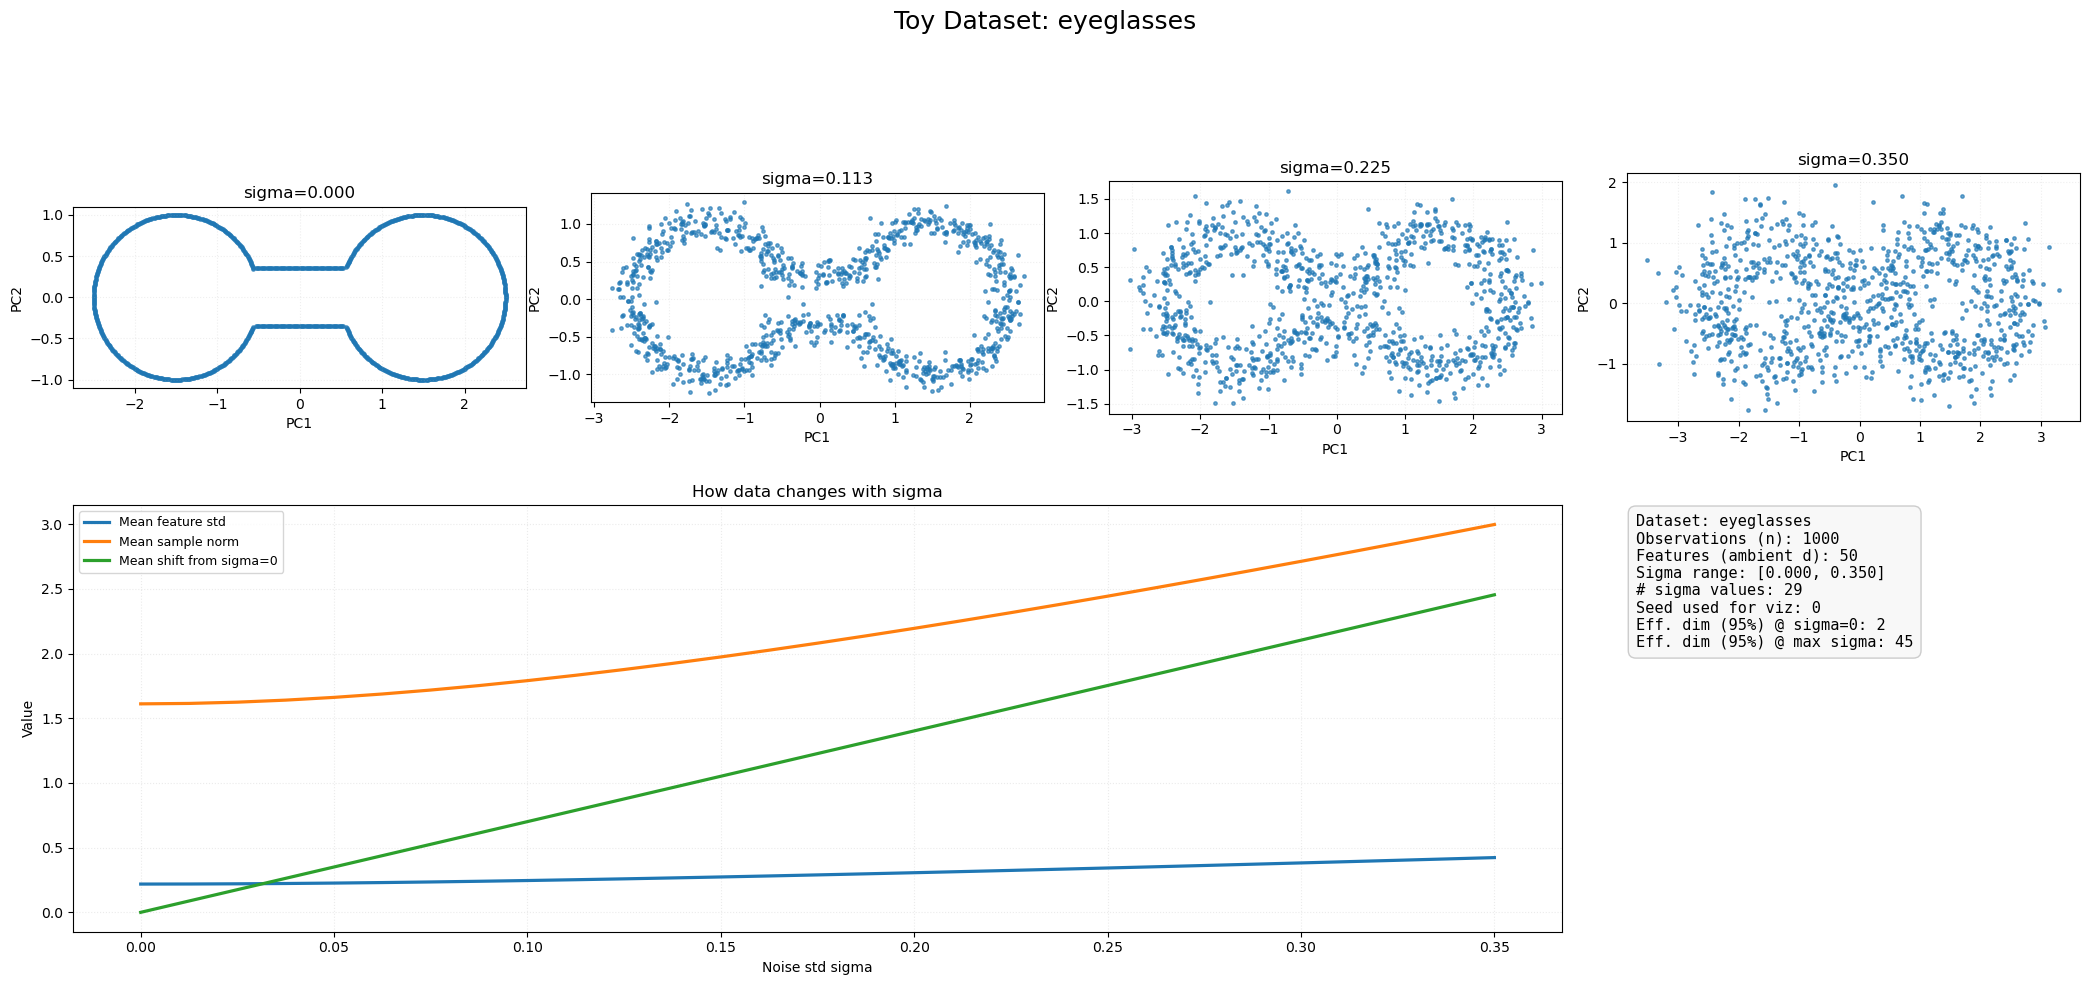

Saved: data/figures/toy_dataset_overview/toy_overview_eyeglasses.pdf
Saved: data/figures/toy_dataset_overview/toy_overview_eyeglasses.png

------------------------------------------------------------------------------------------
Dataset: inter_circles


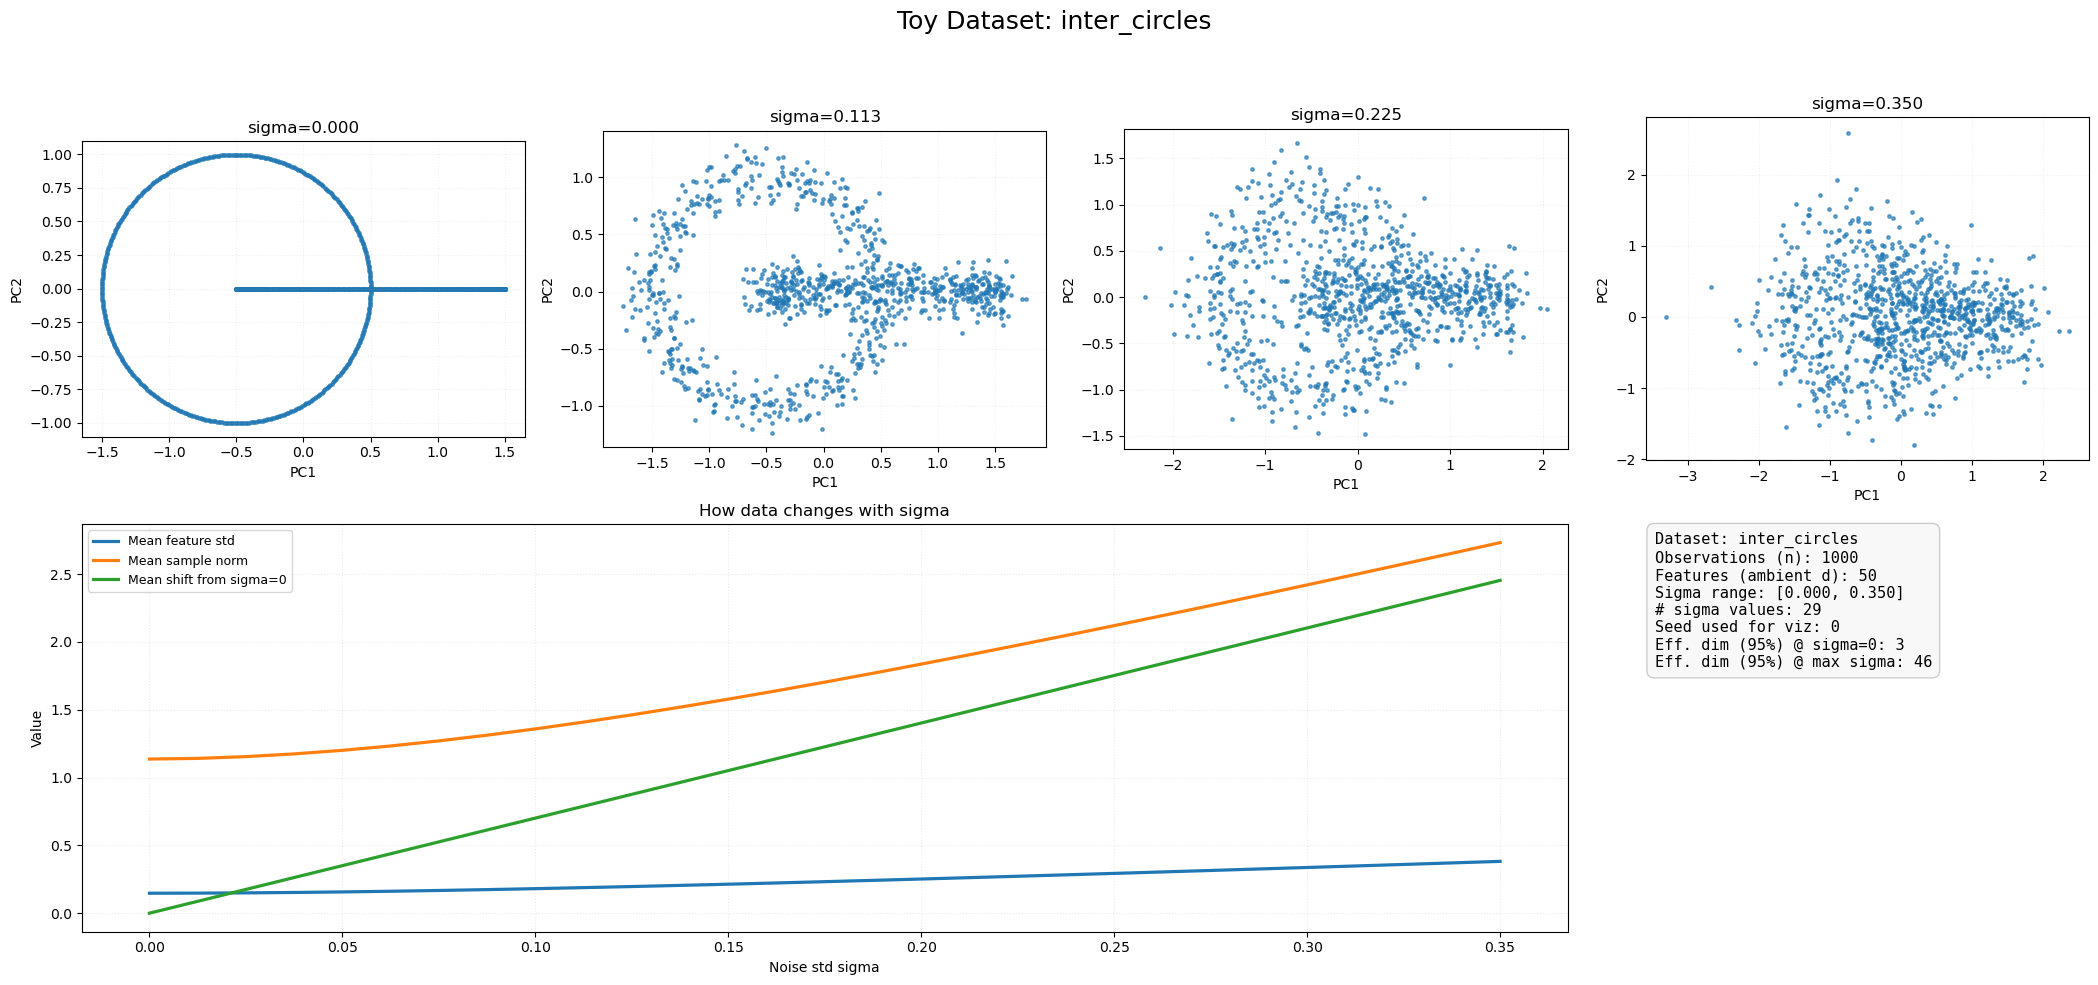

Saved: data/figures/toy_dataset_overview/toy_overview_inter_circles.pdf
Saved: data/figures/toy_dataset_overview/toy_overview_inter_circles.png

------------------------------------------------------------------------------------------
Dataset: toy_circle


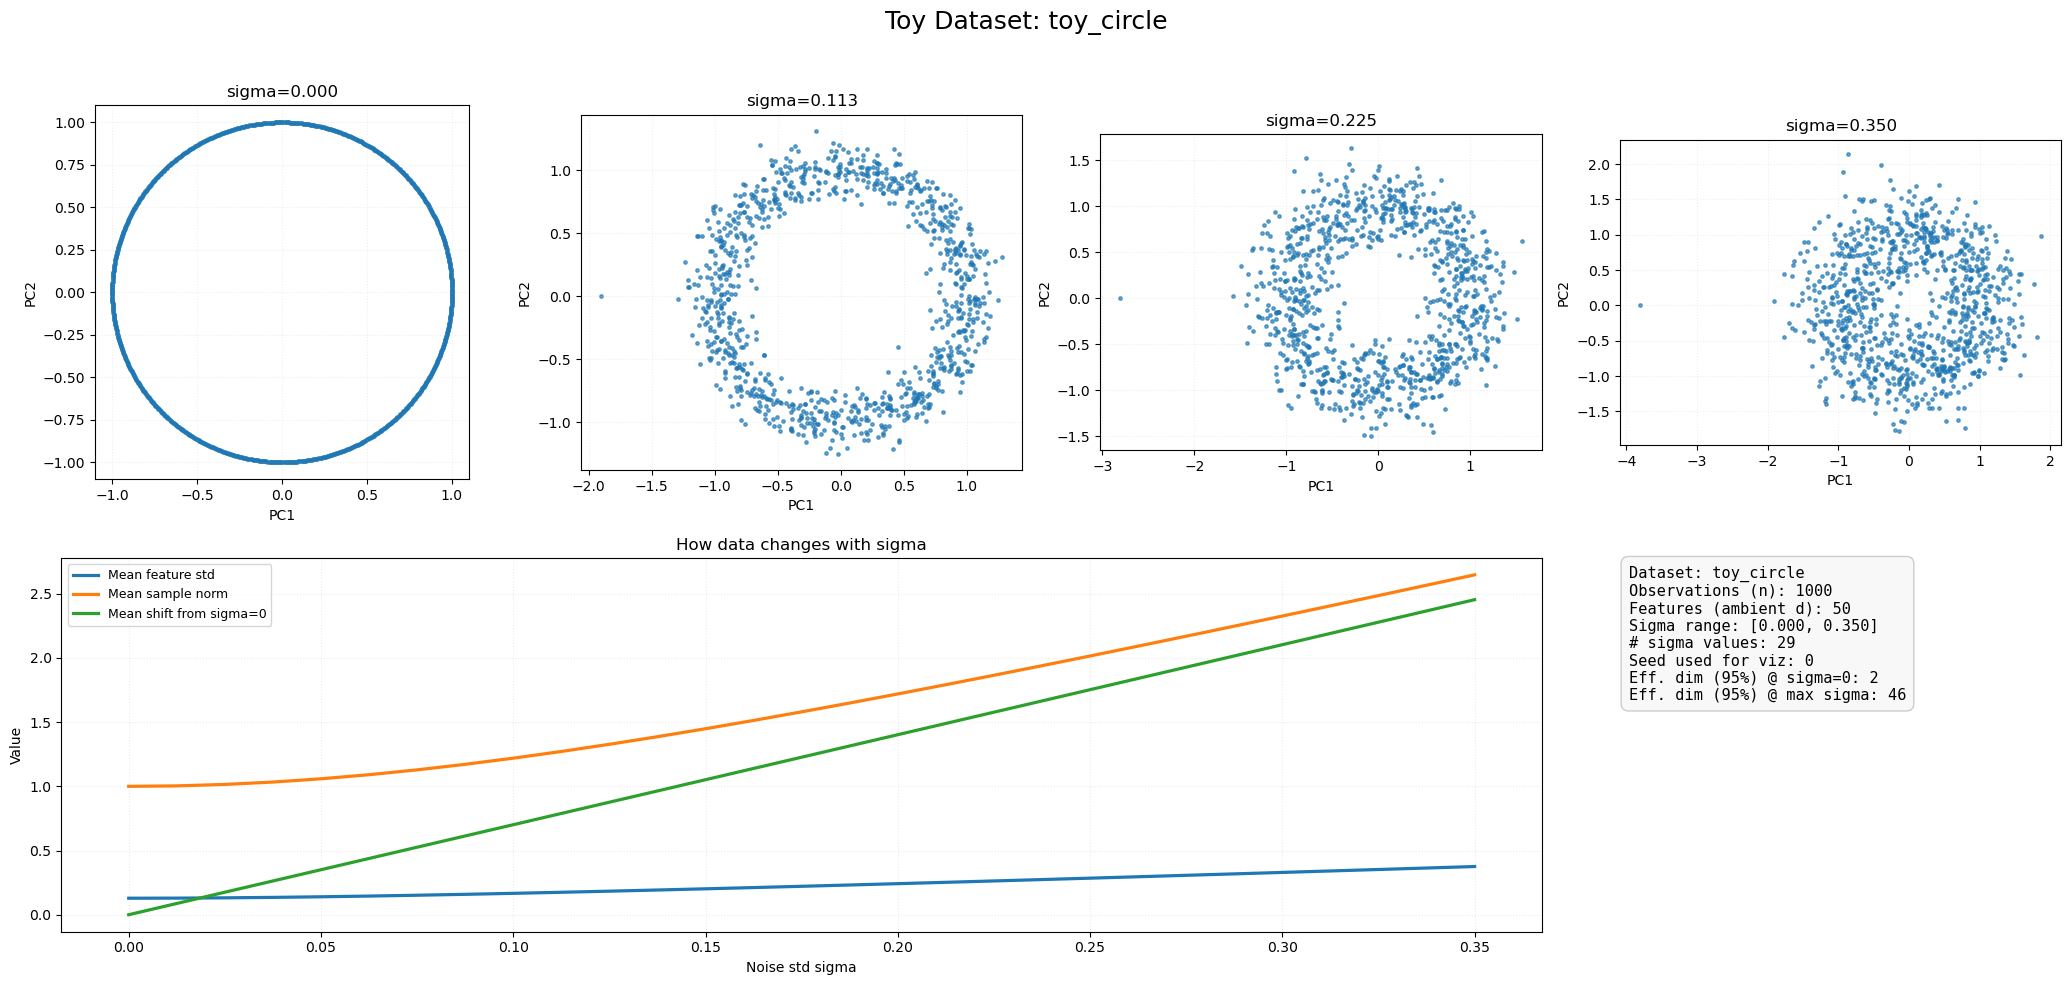

Saved: data/figures/toy_dataset_overview/toy_overview_toy_circle.pdf
Saved: data/figures/toy_dataset_overview/toy_overview_toy_circle.png

------------------------------------------------------------------------------------------
Dataset: toy_sphere


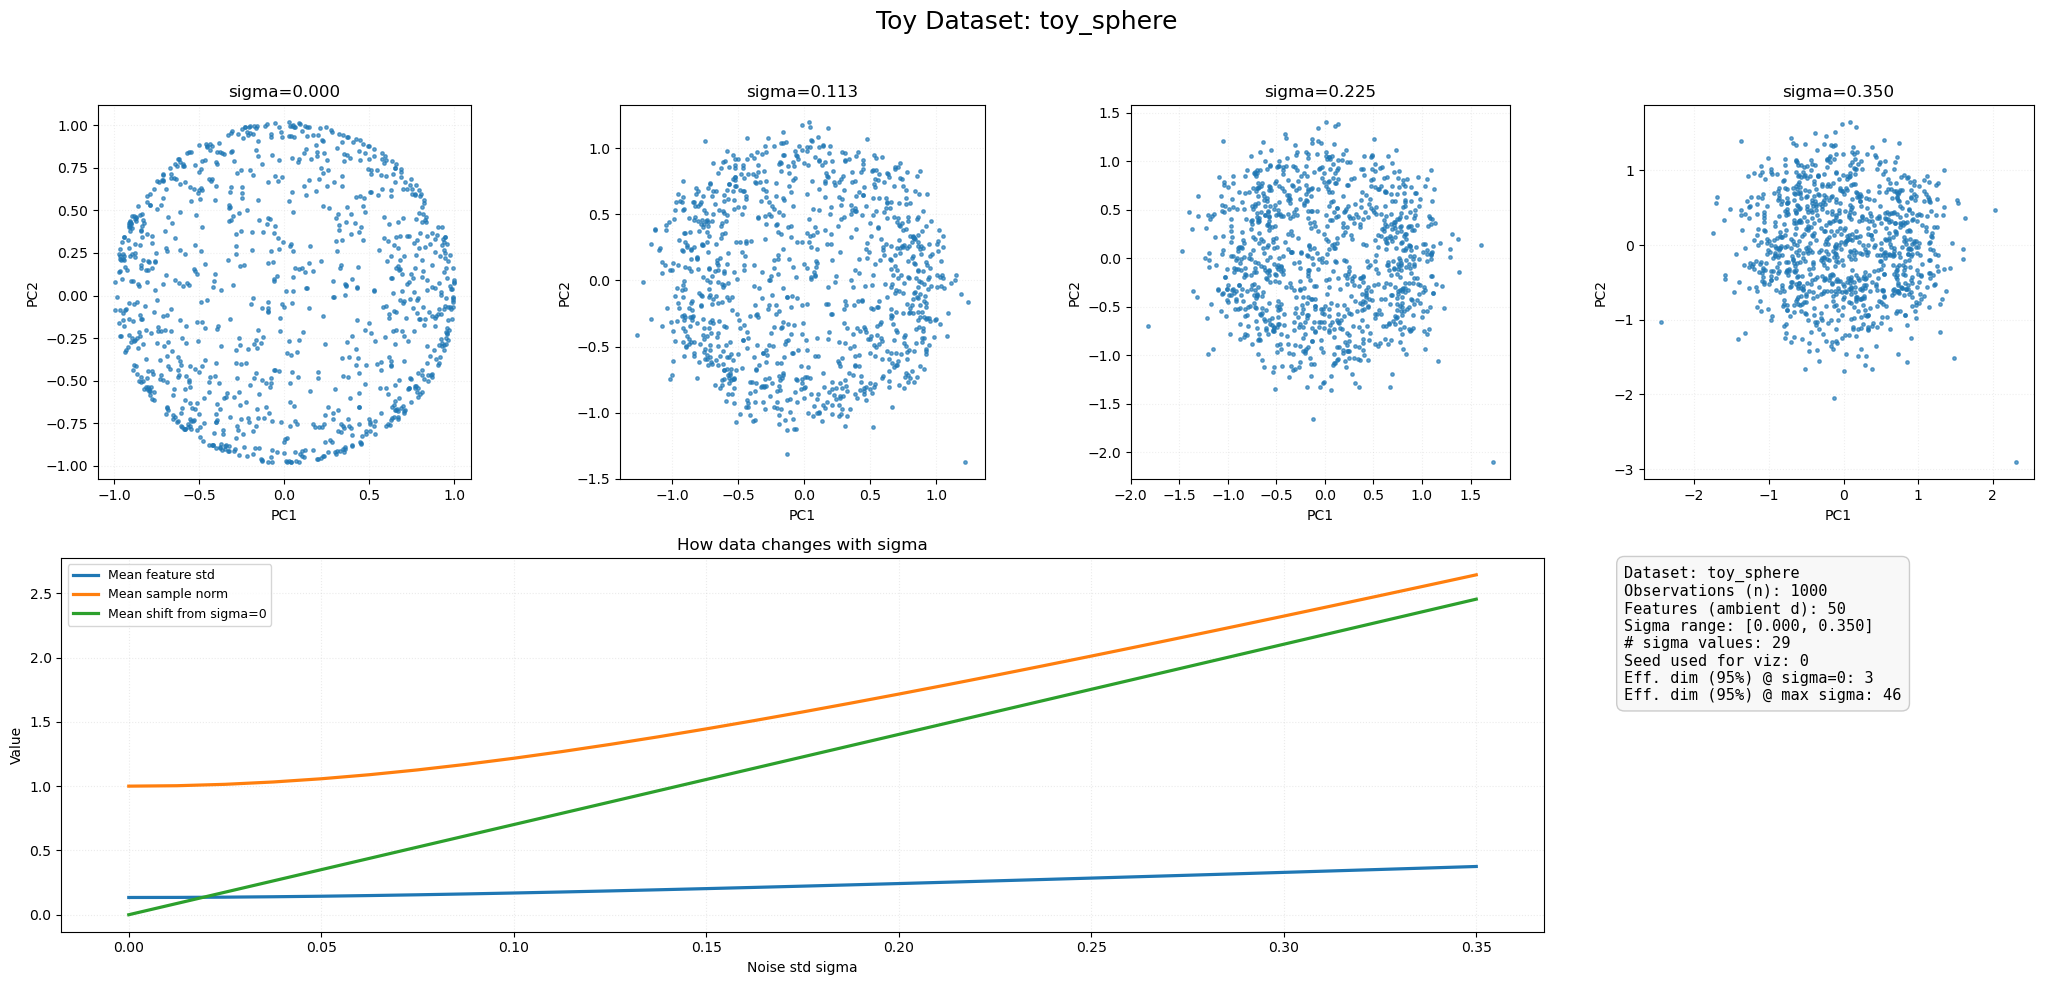

Saved: data/figures/toy_dataset_overview/toy_overview_toy_sphere.pdf
Saved: data/figures/toy_dataset_overview/toy_overview_toy_sphere.png

Completed toy dataset overview figures. Output folder: data/figures/toy_dataset_overview


In [84]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("\n" + "=" * 90)
print("TOY DATASET OVERVIEW: GEOMETRY + METADATA + SIGMA EFFECT")
print("=" * 90)

# Auto-discover candidate toy datasets from data directory
data_entries = os.listdir(root_path)
raw_based = sorted({f.replace("_raw.npz", "") for f in data_entries if f.endswith("_raw.npz")})
toy_dirs = sorted([
    d for d in data_entries
    if d.startswith("toy_") and os.path.isdir(os.path.join(root_path, d))
])

# Include known toy datasets used in this project
known_toy = ["toy_circle", "eyeglasses", "inter_circles", "toy_sphere"]
candidate_datasets = sorted(set(raw_based + toy_dirs + known_toy))

# Keep only datasets that can actually be generated by get_toy_data
available_toy_datasets = []
for ds in candidate_datasets:
    try:
        _ = get_toy_data(n=min(n, 200), dataset=ds, d=d, seed=0, gaussian={"sigma": 0.0})
        available_toy_datasets.append(ds)
    except Exception:
        pass

if not available_toy_datasets:
    raise ValueError("No toy datasets available from get_toy_data with current setup.")

print(f"Datasets found: {available_toy_datasets}")

# Sigma snapshots for visual panels
if len(sigmas) >= 4:
    snapshot_idx = np.linspace(0, len(sigmas) - 1, 4, dtype=int)
    sigma_snapshots = sigmas[snapshot_idx]
else:
    sigma_snapshots = sigmas

# Figure output folder
toy_fig_dir = os.path.join(fig_path, "toy_dataset_overview")
os.makedirs(toy_fig_dir, exist_ok=True)

for ds in available_toy_datasets:
    print("\n" + "-" * 90)
    print(f"Dataset: {ds}")

    seed_for_viz = 0

    # Clean reference sample (sigma = 0)
    X_clean = get_toy_data(n=n, dataset=ds, d=d, seed=seed_for_viz, gaussian={"sigma": 0.0})
    n_obs, n_features = X_clean.shape

    # PCA basis from clean data for consistent geometry comparison
    pca_2d = PCA(n_components=2)
    pca_2d.fit(X_clean)

    # Layout: top row = geometry snapshots, bottom row = trends + metadata
    fig, axes = plt.subplots(2, 4, figsize=(21, 10))
    fig.suptitle(f"Toy Dataset: {ds}", fontsize=18, y=0.98)

    # Top row: dataset geometry at selected sigma snapshots
    for j, sigma_val in enumerate(sigma_snapshots):
        X_sigma = get_toy_data(n=n, dataset=ds, d=d, seed=seed_for_viz, gaussian={"sigma": float(sigma_val)})
        X_2d = pca_2d.transform(X_sigma)

        axes[0, j].scatter(X_2d[:, 0], X_2d[:, 1], s=6, alpha=0.65)
        axes[0, j].set_title(f"sigma={sigma_val:.3f}", fontsize=12)
        axes[0, j].set_xlabel("PC1")
        axes[0, j].set_ylabel("PC2")
        axes[0, j].grid(alpha=0.2, linestyle=":")
        axes[0, j].set_aspect("equal", adjustable="box")

    # Bottom-left (spanning 3 columns): trend metrics across all sigmas
    for col in [0, 1, 2]:
        axes[1, col].remove()

    trend_ax = fig.add_subplot(2, 4, (5, 7))

    mean_feature_std = []
    mean_sample_norm = []
    mean_shift_from_clean = []

    for sigma_val in sigmas:
        X_sigma = get_toy_data(n=n, dataset=ds, d=d, seed=seed_for_viz, gaussian={"sigma": float(sigma_val)})
        mean_feature_std.append(float(np.mean(np.std(X_sigma, axis=0))))
        mean_sample_norm.append(float(np.mean(np.linalg.norm(X_sigma, axis=1))))
        mean_shift_from_clean.append(float(np.mean(np.linalg.norm(X_sigma - X_clean, axis=1))))

    trend_ax.plot(sigmas, mean_feature_std, linewidth=2.3, label="Mean feature std")
    trend_ax.plot(sigmas, mean_sample_norm, linewidth=2.3, label="Mean sample norm")
    trend_ax.plot(sigmas, mean_shift_from_clean, linewidth=2.3, label="Mean shift from sigma=0")
    trend_ax.set_title("How data changes with sigma", fontsize=12)
    trend_ax.set_xlabel("Noise std sigma")
    trend_ax.set_ylabel("Value")
    trend_ax.grid(alpha=0.25, linestyle=":")
    trend_ax.legend(fontsize=9, frameon=True)

    # Bottom-right: metadata panel
    meta_ax = axes[1, 3]
    meta_ax.axis("off")

    # Effective dimensionality (95% variance) at low and high sigma
    pca_full_clean = PCA().fit(X_clean)
    eff_dim_clean = int(np.searchsorted(np.cumsum(pca_full_clean.explained_variance_ratio_), 0.95) + 1)

    X_max_sigma = get_toy_data(n=n, dataset=ds, d=d, seed=seed_for_viz, gaussian={"sigma": float(sigmas[-1])})
    pca_full_max = PCA().fit(X_max_sigma)
    eff_dim_max = int(np.searchsorted(np.cumsum(pca_full_max.explained_variance_ratio_), 0.95) + 1)

    metadata_text = (
        f"Dataset: {ds}\n"
        f"Observations (n): {n_obs}\n"
        f"Features (ambient d): {n_features}\n"
        f"Sigma range: [{sigmas[0]:.3f}, {sigmas[-1]:.3f}]\n"
        f"# sigma values: {len(sigmas)}\n"
        f"Seed used for viz: {seed_for_viz}\n"
        f"Eff. dim (95%) @ sigma=0: {eff_dim_clean}\n"
        f"Eff. dim (95%) @ max sigma: {eff_dim_max}"
    )

    meta_ax.text(
        0.02,
        0.98,
        metadata_text,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f8f8", edgecolor="#cccccc")
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save outputs
    out_pdf = os.path.join(toy_fig_dir, f"toy_overview_{ds}.pdf")
    out_png = os.path.join(toy_fig_dir, f"toy_overview_{ds}.png")
    fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
    fig.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")

print("\n" + "=" * 90)
print(f"Completed toy dataset overview figures. Output folder: {toy_fig_dir}")
print("=" * 90)